# CO5430 - Image Processing Project
# Melanoma Skin Cancer Detection & Explainable AI (Grad-CAM)
### Complete End-to-End Experimental Pipeline: Exploration, Baseline, Transfer Learning, Evaluation & Interpretability

---

## 📋 Project Summary
This master notebook implements the complete research workflow for automated binary classification of dermoscopic skin lesion images into **Benign** vs. **Malignant (Melanoma)**.

### Key Stages Covered:
1. **Stage 1 - Data Audit & Exploration:** Verification of dataset integrity, class distribution, image dimensions, and RGB channel normalization stats.
2. **Stage 2 - Baseline CNN (From Scratch):** Custom 3-block convolutional neural network serving as the empirical baseline.
3. **Stage 3 - Transfer Learning & Model Adaptations:**
   - **ResNet-18 (Feature Extraction):** Frozen backbone, classifier head training.
   - **ResNet-18 (Fine-Tuning):** Layer3 + Layer4 + Classifier training with low learning rate.
   - **EfficientNet-B0 (Fine-Tuning):** High-efficiency compound scaling backbone.
4. **Stage 4 - Comprehensive Evaluation & Comparative Ablation:** Multi-model comparative analysis on Test set (Accuracy, Precision, Sensitivity/Recall, Specificity, F1-Score, ROC-AUC, PR-AUC, Confusion Matrices).
5. **Stage 5 - Error & Misclassification Analysis:** Diagnostic inspection of False Positives & False Negatives.
6. **Stage 6 - Interpretability via Grad-CAM:** Saliency mapping on convolutional feature maps across 4 clinical prediction groups (Correct Benign, Correct Malignant, False Positive, False Negative) and cross-model comparison.

---

# Part 0: Environment Setup & Global Configuration

In [1]:
import subprocess, sys
# Ensure required libraries are installed
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn', 'seaborn', 'opencv-python-headless'], check=True)
print("Dependencies installed and verified.")

Dependencies installed and verified.


In [2]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix, average_precision_score
)

# ── Style & Reproducibility ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"[System] PyTorch Version : {torch.__version__}")
print(f"[System] Execution Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"[System] GPU Model       : {torch.cuda.get_device_name(0)}")

# ── Global Hyperparameters ───────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
PATIENCE   = 5
VAL_SPLIT  = 0.10

# Output directories
OUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('./results')
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"[System] Artifacts Target: {OUT_DIR.resolve()}")

[System] PyTorch Version : 2.10.0+cu128
[System] Execution Device: cuda
[System] GPU Model       : Tesla T4
[System] Artifacts Target: /kaggle/working


# Part 1: Dataset Discovery, Audit & Normalization Statistics

In [3]:
def find_dataset_root():
    """Auto-detect dataset directory on Kaggle or local environments."""
    candidates = [
        Path('/kaggle/input'),
        Path('./data'),
        Path('../data'),
    ]
    for base in candidates:
        if not base.exists():
            continue
        for root, dirs, files in os.walk(base):
            dirs_lower = {d.lower() for d in dirs}
            if 'train' in dirs_lower and 'test' in dirs_lower:
                return Path(root).resolve()
            if 'benign' in dirs_lower or 'malignant' in dirs_lower:
                return Path(root).parent.resolve()
    raise FileNotFoundError(
        "Dataset not found! Please attach 'melanoma-cancer-dataset' in Kaggle (+ Add Input) or place in ./data"
    )

DATA_ROOT = find_dataset_root()
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'

print(f"Dataset Root : {DATA_ROOT}")
print(f"Train Folder : {TRAIN_DIR}")
print(f"Test Folder  : {TEST_DIR}")

Dataset Root : /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset
Train Folder : /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/train
Test Folder  : /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/test


Total Images Found: 13,879


class,Benign,Malignant
split,,
test,1000,1000
train,6289,5590


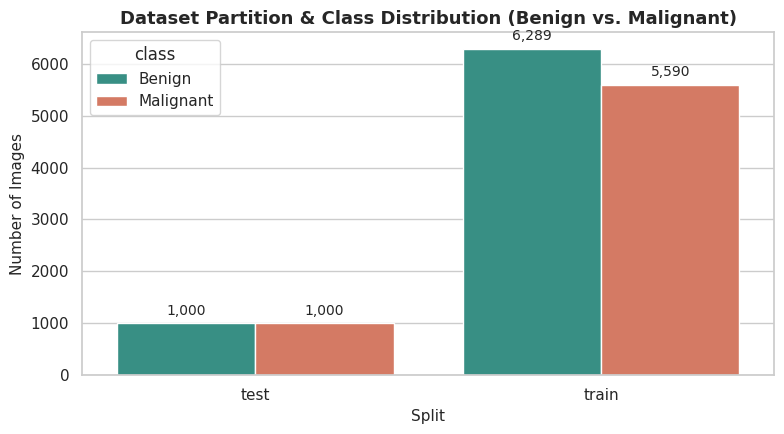

In [4]:
# ── Audit Dataset Counts & Class Balance ─────────────────────────────────────
image_extensions = {'.jpg', '.jpeg', '.png'}
records = []

for root, dirs, files in os.walk(DATA_ROOT):
    rel = Path(root).relative_to(DATA_ROOT)
    parts = rel.parts
    if len(parts) >= 2:
        split = parts[0]
        cls = parts[-1]
        for f in files:
            if Path(f).suffix.lower() in image_extensions:
                records.append({
                    'split': split,
                    'class': cls.capitalize(),
                    'path': str(Path(root) / f)
                })

df_meta = pd.DataFrame(records)
print(f"Total Images Found: {len(df_meta):,}")

summary_table = df_meta.groupby(['split', 'class']).size().unstack(fill_value=0)
display(summary_table)

# Visualise class distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=df_meta, x='split', hue='class', palette=['#2A9D8F', '#E76F51'], ax=ax)
ax.set_title("Dataset Partition & Class Distribution (Benign vs. Malignant)", fontsize=13, fontweight='bold')
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'dataset_class_distribution.png', dpi=150)
plt.show()

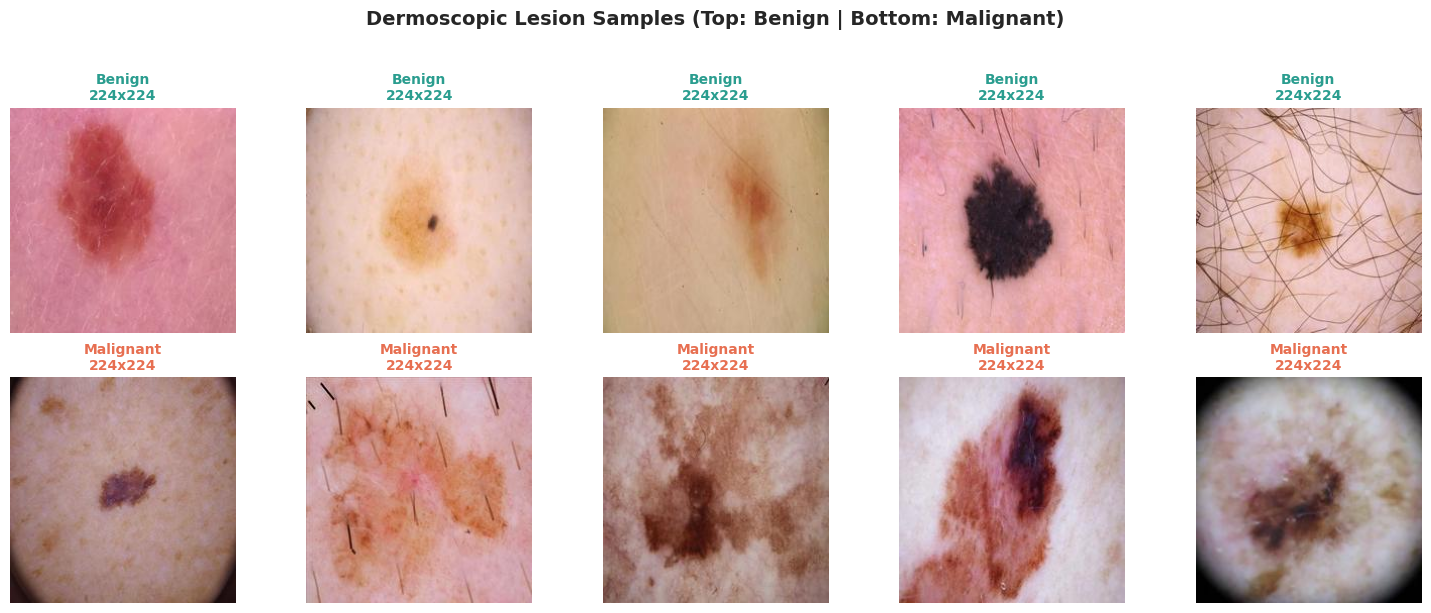

In [5]:
# ── Visualise Raw Dermoscopy Samples ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
benign_samples = df_meta[df_meta['class'] == 'Benign'].sample(5, random_state=SEED)
malignant_samples = df_meta[df_meta['class'] == 'Malignant'].sample(5, random_state=SEED)

for idx, (_, row) in enumerate(benign_samples.reset_index().iterrows()):
    img = Image.open(row['path'])
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f"Benign\n{img.size[0]}x{img.size[1]}", color='#2A9D8F', fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')

for idx, (_, row) in enumerate(malignant_samples.reset_index().iterrows()):
    img = Image.open(row['path'])
    axes[1, idx].imshow(img)
    axes[1, idx].set_title(f"Malignant\n{img.size[0]}x{img.size[1]}", color='#E76F51', fontsize=10, fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle("Dermoscopic Lesion Samples (Top: Benign | Bottom: Malignant)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sample_images_inspection.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Compute Per-Channel RGB Mean and Std ─────────────────────────────────────
print("Calculating exact RGB Mean & Std on a sample of training images...")
train_sample = df_meta[df_meta['split'] == 'train'].sample(min(1200, len(df_meta[df_meta['split'] == 'train'])), random_state=SEED)
means, sq_means = [], []

for _, row in train_sample.iterrows():
    with Image.open(row['path']) as img:
        arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        sq_means.append((arr ** 2).mean(axis=(0, 1)))

DATASET_MEAN = [float(x) for x in np.round(np.mean(means, axis=0), 4)]
rgb_sq       = np.mean(sq_means, axis=0)
DATASET_STD  = [float(x) for x in np.round(np.sqrt(np.maximum(rgb_sq - np.array(DATASET_MEAN)**2, 0.0)), 4)]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"[Normalization] Dataset Computed Mean: {DATASET_MEAN}")
print(f"[Normalization] Dataset Computed Std : {DATASET_STD}")
print(f"[Normalization] ImageNet Default Mean: {IMAGENET_MEAN}")
print(f"[Normalization] ImageNet Default Std : {IMAGENET_STD}")

Calculating exact RGB Mean & Std on a sample of training images...
[Normalization] Dataset Computed Mean: [0.7211999893188477, 0.5557000041007996, 0.539900004863739]
[Normalization] Dataset Computed Std : [0.2168, 0.2064, 0.2191]
[Normalization] ImageNet Default Mean: [0.485, 0.456, 0.406]
[Normalization] ImageNet Default Std : [0.229, 0.224, 0.225]


# Part 2: DataLoaders & Preprocessing Pipelines
We create two transformation pipelines:
1. **Dataset-Specific Normalization:** Used for the Baseline CNN trained from scratch.
2. **ImageNet Normalization:** Required for pretrained Transfer Learning models (ResNet-18 & EfficientNet-B0).

In [7]:
def build_dataloaders(use_imagenet_norm=False, batch_size=BATCH_SIZE):
    mean = IMAGENET_MEAN if use_imagenet_norm else DATASET_MEAN
    std  = IMAGENET_STD  if use_imagenet_norm else DATASET_STD

    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    full_train_aug   = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
    full_train_clean = datasets.ImageFolder(str(TRAIN_DIR), transform=eval_transform)
    test_dataset     = datasets.ImageFolder(str(TEST_DIR),  transform=eval_transform)

    n_total = len(full_train_aug)
    n_val   = int(n_total * VAL_SPLIT)
    n_train = n_total - n_val

    gen = torch.Generator().manual_seed(SEED)
    train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=gen)

    train_subset = Subset(full_train_aug,   train_idx.indices)
    val_subset   = Subset(full_train_clean, val_idx.indices)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, full_train_aug.classes

# Build DataLoaders
train_ldr_ds, val_ldr_ds, test_ldr_ds, CLASS_NAMES = build_dataloaders(use_imagenet_norm=False)
train_ldr_im, val_ldr_im, test_ldr_im, _           = build_dataloaders(use_imagenet_norm=True)

print(f"Classes Identified: {CLASS_NAMES}")
print(f"Train Samples     : {len(train_ldr_ds.dataset):,}")
print(f"Validation Samples: {len(val_ldr_ds.dataset):,}")
print(f"Test Samples      : {len(test_ldr_ds.dataset):,}")

Classes Identified: ['Benign', 'Malignant']
Train Samples     : 10,692
Validation Samples: 1,187
Test Samples      : 2,000


# Part 3: Shared Training Engine & Evaluation Utilities

In [9]:
def train_model(
    model, train_loader, val_loader, *,
    epochs=15, lr=1e-3, weight_decay=1e-4, patience=PATIENCE,
    save_path=None, model_label="Model"
):
    """Standardized binary classification training loop with Cosine Annealing and Early Stopping."""
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 1e-3)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"\n{'='*70}")
    print(f"  Training: {model_label} (Epochs: {epochs}, LR: {lr:.2e})")
    print(f"{'='*70}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── Training Phase ───────────────────────────────────────────
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            loss.backward()
            optimizer.step()

            tr_loss    += loss.item() * imgs.size(0)
            preds       = (torch.sigmoid(logits.detach()) >= 0.5).long()
            tr_correct += (preds == lbls.long()).sum().item()
            tr_total   += imgs.size(0)

        tr_loss /= tr_total
        tr_acc   = tr_correct / tr_total

        # ── Validation Phase ─────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.float().unsqueeze(1).to(DEVICE)
                logits = model(imgs)
                v_loss    += criterion(logits, lbls).item() * imgs.size(0)
                preds      = (torch.sigmoid(logits) >= 0.5).long()
                v_correct += (preds == lbls.long()).sum().item()
                v_total   += imgs.size(0)

        v_loss /= v_total
        v_acc   = v_correct / v_total

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['lr'].append(current_lr)

        elapsed = time.time() - t0
        print(f"Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
              f"Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f} | LR: {current_lr:.2e} ({elapsed:.1f}s)")

        # ── Checkpoint & Early Stopping ──────────────────────────────
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  [✓] Best model checkpoint saved (val_loss={best_val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  [!] Early stopping triggered after {patience} epochs without improvement.")
                break

    return history

In [10]:
def evaluate_model(model, loader, threshold=0.5):
    """Compute all clinical & statistical evaluation metrics on a test set."""
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            probs = torch.sigmoid(model(imgs.to(DEVICE)).squeeze(1)).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(lbls.numpy().tolist())

    probs  = np.array(all_probs)
    labels = np.array(all_labels)
    preds  = (probs >= threshold).astype(int)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        'accuracy':    float(accuracy_score(labels, preds)),
        'precision':   float(precision_score(labels, preds, zero_division=0)),
        'recall':      float(recall_score(labels, preds, zero_division=0)),       # Sensitivity
        'specificity': float(specificity),
        'f1':          float(f1_score(labels, preds, zero_division=0)),
        'roc_auc':     float(roc_auc_score(labels, probs)),
        'pr_auc':      float(average_precision_score(labels, probs)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'n_samples':   len(labels)
    }
    return metrics, probs, labels

def plot_curves(history, save_path, title):
    ep = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    ax1.plot(ep, history['train_loss'], label='Train Loss', color='#E76F51', lw=2)
    ax1.plot(ep, history['val_loss'],   label='Val Loss',   color='#2A9D8F', lw=2)
    ax1.set_title(f"{title} — Loss", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, history['train_acc'], label='Train Acc', color='#E76F51', lw=2)
    ax2.plot(ep, history['val_acc'],   label='Val Acc',   color='#2A9D8F', lw=2)
    ax2.set_title(f"{title} — Accuracy", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()

# Part 4: Stage 2 — Baseline CNN (Trained from Scratch)
A custom 3-block convolutional neural network designed specifically for dermoscopy baseline comparison.

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class BaselineCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),   # 224 -> 112
            ConvBlock(32,  64,  pool=True),   # 112 -> 56
            ConvBlock(64,  128, pool=True),   #  56 -> 28
        )
        self.gap = nn.AdaptiveAvgPool2d(1)    # (B, 128, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

model_baseline = BaselineCNN().to(DEVICE)
total_p = sum(p.numel() for p in model_baseline.parameters())
train_p = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"BaselineCNN | Total Parameters: {total_p:,} | Trainable: {train_p:,}")

BaselineCNN | Total Parameters: 101,793 | Trainable: 101,793



  Training: Baseline CNN (Scratch) (Epochs: 20, LR: 1.00e-03)
Epoch [01/20] | Train Loss: 0.5002, Acc: 0.7561 | Val Loss: 0.4965, Acc: 0.7422 | LR: 9.94e-04 (53.8s)
  [✓] Best model checkpoint saved (val_loss=0.4965)
Epoch [02/20] | Train Loss: 0.4428, Acc: 0.7921 | Val Loss: 0.4617, Acc: 0.7793 | LR: 9.76e-04 (32.6s)
  [✓] Best model checkpoint saved (val_loss=0.4617)
Epoch [03/20] | Train Loss: 0.4100, Acc: 0.8086 | Val Loss: 0.3482, Acc: 0.8509 | LR: 9.46e-04 (32.6s)
  [✓] Best model checkpoint saved (val_loss=0.3482)
Epoch [04/20] | Train Loss: 0.3910, Acc: 0.8228 | Val Loss: 0.3531, Acc: 0.8256 | LR: 9.05e-04 (32.6s)
Epoch [05/20] | Train Loss: 0.3784, Acc: 0.8306 | Val Loss: 0.3850, Acc: 0.8214 | LR: 8.54e-04 (33.0s)
Epoch [06/20] | Train Loss: 0.3715, Acc: 0.8347 | Val Loss: 0.3309, Acc: 0.8576 | LR: 7.94e-04 (32.8s)
  [✓] Best model checkpoint saved (val_loss=0.3309)
Epoch [07/20] | Train Loss: 0.3654, Acc: 0.8354 | Val Loss: 0.3568, Acc: 0.8408 | LR: 7.27e-04 (33.2s)
Epoch [0

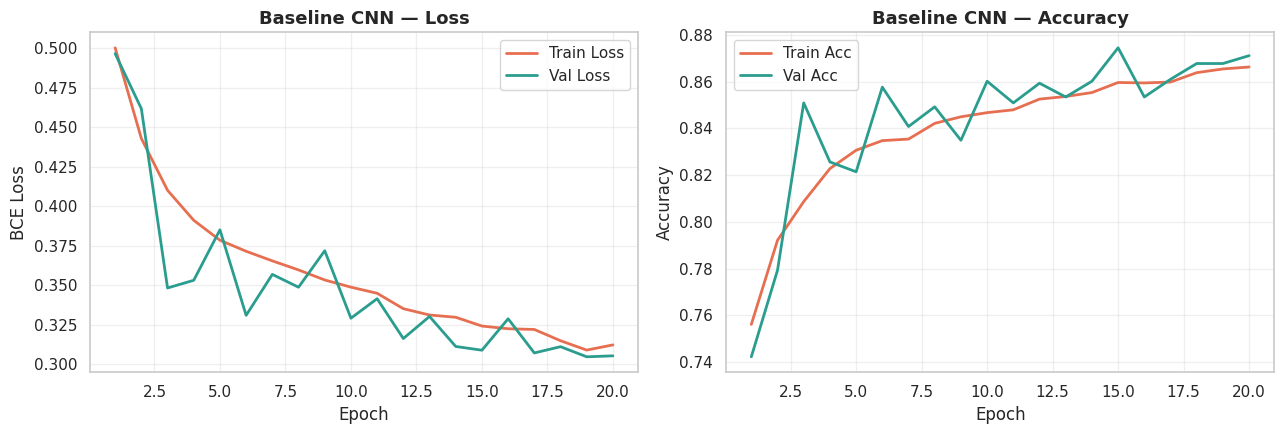


--- Baseline CNN Test Performance ---
  accuracy       : 0.8600
  precision      : 0.9000
  recall         : 0.8100
  specificity    : 0.9100
  f1             : 0.8526
  roc_auc        : 0.9446
  pr_auc         : 0.9350
  tn             : 910
  fp             : 90
  fn             : 190
  tp             : 810
  n_samples      : 2000


In [12]:
SAVE_BASELINE = OUT_DIR / 'baseline_cnn.pt'
history_baseline = train_model(
    model_baseline,
    train_ldr_ds,
    val_ldr_ds,
    epochs=20,
    lr=1e-3,
    save_path=SAVE_BASELINE,
    model_label="Baseline CNN (Scratch)"
)

plot_curves(history_baseline, FIG_DIR / 'training_curves_baseline.png', "Baseline CNN")

# Load best checkpoint and evaluate
model_baseline.load_state_dict(torch.load(SAVE_BASELINE, map_location=DEVICE))
metrics_baseline, probs_baseline, labels_baseline = evaluate_model(model_baseline, test_ldr_ds)

print("\n--- Baseline CNN Test Performance ---")
for k, v in metrics_baseline.items():
    print(f"  {k:15s}: {v:.4f}" if isinstance(v, float) else f"  {k:15s}: {v}")

# Part 5: Stage 3 — Transfer Learning & Model Adaptations
We investigate three transfer learning strategies:
1. **ResNet-18 (Feature Extraction):** Backbone weights locked; only new classifier head trained.
2. **ResNet-18 (Fine-Tuning):** Layer3, Layer4, and classifier head trained with reduced learning rate.
3. **EfficientNet-B0 (Fine-Tuning):** Highly parameter-efficient compound scaling architecture.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]



  Training: ResNet-18 Feature Extraction (Epochs: 10, LR: 1.00e-03)
Epoch [01/10] | Train Loss: 0.4428, Acc: 0.7897 | Val Loss: 0.3889, Acc: 0.8425 | LR: 9.76e-04 (35.6s)
  [✓] Best model checkpoint saved (val_loss=0.3889)
Epoch [02/10] | Train Loss: 0.3772, Acc: 0.8331 | Val Loss: 0.3593, Acc: 0.8526 | LR: 9.05e-04 (31.6s)
  [✓] Best model checkpoint saved (val_loss=0.3593)
Epoch [03/10] | Train Loss: 0.3801, Acc: 0.8345 | Val Loss: 0.3456, Acc: 0.8593 | LR: 7.94e-04 (31.5s)
  [✓] Best model checkpoint saved (val_loss=0.3456)
Epoch [04/10] | Train Loss: 0.3681, Acc: 0.8364 | Val Loss: 0.3949, Acc: 0.8366 | LR: 6.55e-04 (30.6s)
Epoch [05/10] | Train Loss: 0.3730, Acc: 0.8369 | Val Loss: 0.3885, Acc: 0.8450 | LR: 5.01e-04 (30.8s)
Epoch [06/10] | Train Loss: 0.3515, Acc: 0.8479 | Val Loss: 0.3704, Acc: 0.8500 | LR: 3.46e-04 (30.7s)
Epoch [07/10] | Train Loss: 0.3529, Acc: 0.8482 | Val Loss: 0.3413, Acc: 0.8627 | LR: 2.07e-04 (30.7s)
  [✓] Best model checkpoint saved (val_loss=0.3413)
Ep

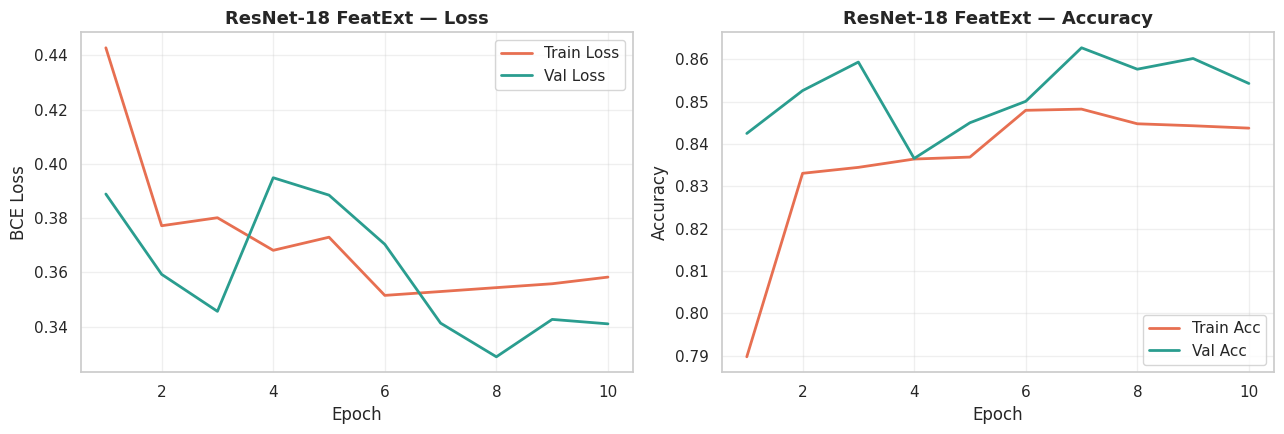

In [14]:
# ── 1. ResNet-18 Feature Extraction ──────────────────────────────────────────
def build_resnet18_feat_ext():
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in base.parameters():
        param.requires_grad = False
    base.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(base.fc.in_features, 1)
    )
    return base

model_fe = build_resnet18_feat_ext().to(DEVICE)
SAVE_FE = OUT_DIR / 'resnet18_feature_extraction.pt'

history_fe = train_model(
    model_fe, train_ldr_im, val_ldr_im,
    epochs=10, lr=1e-3,
    save_path=SAVE_FE, model_label="ResNet-18 Feature Extraction"
)
plot_curves(history_fe, FIG_DIR / 'training_curves_resnet18_feat_ext.png', "ResNet-18 FeatExt")

model_fe.load_state_dict(torch.load(SAVE_FE, map_location=DEVICE))
metrics_fe, probs_fe, labels_fe = evaluate_model(model_fe, test_ldr_im)


  Training: ResNet-18 Fine-Tuned (Epochs: 15, LR: 3.00e-04)
Epoch [01/15] | Train Loss: 0.3101, Acc: 0.8650 | Val Loss: 0.2419, Acc: 0.9040 | LR: 2.97e-04 (31.6s)
  [✓] Best model checkpoint saved (val_loss=0.2419)
Epoch [02/15] | Train Loss: 0.2538, Acc: 0.8953 | Val Loss: 0.2265, Acc: 0.8997 | LR: 2.87e-04 (31.6s)
  [✓] Best model checkpoint saved (val_loss=0.2265)
Epoch [03/15] | Train Loss: 0.2340, Acc: 0.8970 | Val Loss: 0.2171, Acc: 0.9115 | LR: 2.71e-04 (32.0s)
  [✓] Best model checkpoint saved (val_loss=0.2171)
Epoch [04/15] | Train Loss: 0.2223, Acc: 0.9047 | Val Loss: 0.2369, Acc: 0.9048 | LR: 2.50e-04 (31.7s)
Epoch [05/15] | Train Loss: 0.2070, Acc: 0.9148 | Val Loss: 0.2223, Acc: 0.9107 | LR: 2.25e-04 (32.2s)
Epoch [06/15] | Train Loss: 0.1954, Acc: 0.9187 | Val Loss: 0.2340, Acc: 0.8981 | LR: 1.96e-04 (32.5s)
Epoch [07/15] | Train Loss: 0.1731, Acc: 0.9278 | Val Loss: 0.2288, Acc: 0.9065 | LR: 1.66e-04 (32.9s)
Epoch [08/15] | Train Loss: 0.1579, Acc: 0.9342 | Val Loss: 0.

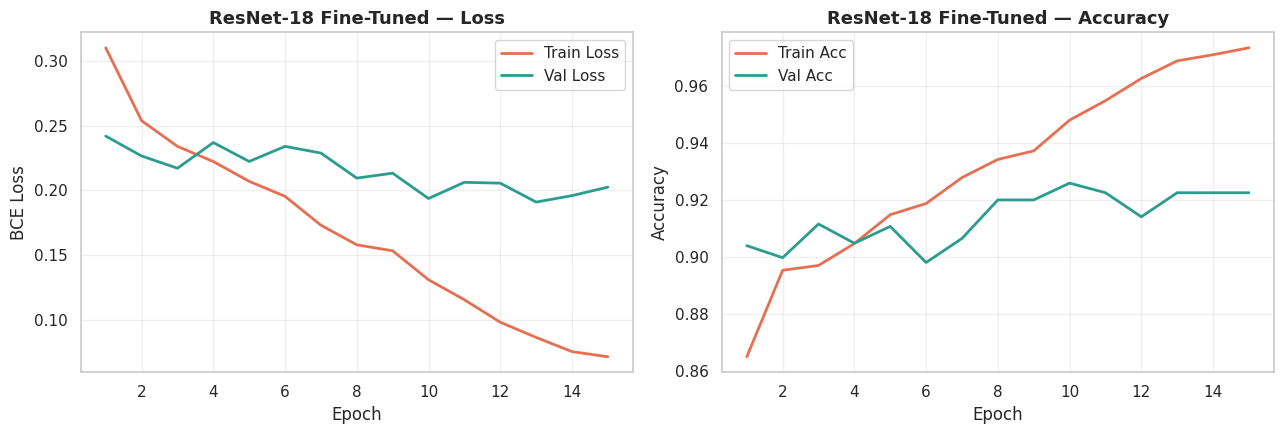

In [15]:
# ── 2. ResNet-18 Fine-Tuning ────────────────────────────────────────────────
def build_resnet18_fine_tuned():
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in base.parameters():
        param.requires_grad = False
    for param in base.layer3.parameters():
        param.requires_grad = True
    for param in base.layer4.parameters():
        param.requires_grad = True
    base.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(base.fc.in_features, 1)
    )
    return base

model_ft = build_resnet18_fine_tuned().to(DEVICE)
SAVE_FT = OUT_DIR / 'resnet18_fine_tuned.pt'

history_ft = train_model(
    model_ft, train_ldr_im, val_ldr_im,
    epochs=15, lr=3e-4,
    save_path=SAVE_FT, model_label="ResNet-18 Fine-Tuned"
)
plot_curves(history_ft, FIG_DIR / 'training_curves_resnet18_fine_tuned.png', "ResNet-18 Fine-Tuned")

model_ft.load_state_dict(torch.load(SAVE_FT, map_location=DEVICE))
metrics_ft, probs_ft, labels_ft = evaluate_model(model_ft, test_ldr_im)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 



  Training: EfficientNet-B0 Fine-Tuned (Epochs: 15, LR: 3.00e-04)
Epoch [01/15] | Train Loss: 0.3308, Acc: 0.8535 | Val Loss: 0.2666, Acc: 0.8854 | LR: 2.97e-04 (32.6s)
  [✓] Best model checkpoint saved (val_loss=0.2666)
Epoch [02/15] | Train Loss: 0.2640, Acc: 0.8893 | Val Loss: 0.2672, Acc: 0.8804 | LR: 2.87e-04 (33.4s)
Epoch [03/15] | Train Loss: 0.2448, Acc: 0.8983 | Val Loss: 0.2643, Acc: 0.8863 | LR: 2.71e-04 (33.1s)
  [✓] Best model checkpoint saved (val_loss=0.2643)
Epoch [04/15] | Train Loss: 0.2355, Acc: 0.9012 | Val Loss: 0.2539, Acc: 0.8905 | LR: 2.50e-04 (33.0s)
  [✓] Best model checkpoint saved (val_loss=0.2539)
Epoch [05/15] | Train Loss: 0.2134, Acc: 0.9120 | Val Loss: 0.2527, Acc: 0.9014 | LR: 2.25e-04 (33.0s)
  [✓] Best model checkpoint saved (val_loss=0.2527)
Epoch [06/15] | Train Loss: 0.2125, Acc: 0.9111 | Val Loss: 0.2496, Acc: 0.8972 | LR: 1.96e-04 (32.8s)
  [✓] Best model checkpoint saved (val_loss=0.2496)
Epoch [07/15] | Train Loss: 0.1989, Acc: 0.9160 | Val L

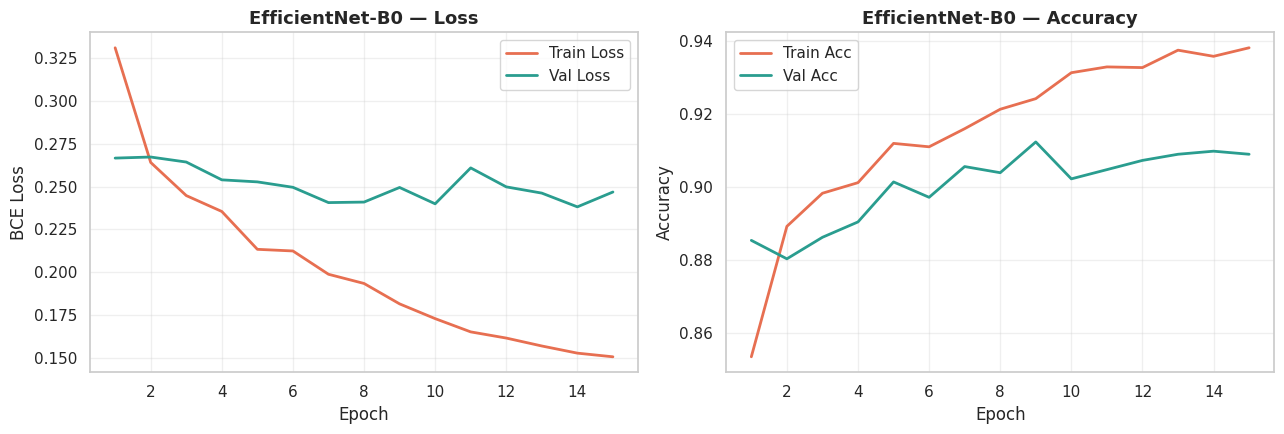

In [16]:
# ── 3. EfficientNet-B0 Fine-Tuning ──────────────────────────────────────────
def build_efficientnet_b0():
    base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in base.parameters():
        param.requires_grad = False
    for param in base.features[7].parameters():
        param.requires_grad = True
    for param in base.features[8].parameters():
        param.requires_grad = True
    in_features = base.classifier[1].in_features
    base.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 1)
    )
    return base

model_eff = build_efficientnet_b0().to(DEVICE)
SAVE_EFF = OUT_DIR / 'efficientnet_b0.pt'

history_eff = train_model(
    model_eff, train_ldr_im, val_ldr_im,
    epochs=15, lr=3e-4,
    save_path=SAVE_EFF, model_label="EfficientNet-B0 Fine-Tuned"
)
plot_curves(history_eff, FIG_DIR / 'training_curves_efficientnet_b0.png', "EfficientNet-B0")

model_eff.load_state_dict(torch.load(SAVE_EFF, map_location=DEVICE))
metrics_eff, probs_eff, labels_eff = evaluate_model(model_eff, test_ldr_im)

# Part 6: Comprehensive Comparative Evaluation (All 4 Models)
We now aggregate all 4 models into the final comparative table and generate publication-quality figures.


  FINAL MODEL COMPARISON TABLE (TEST SET EVALUATION)


,Accuracy,Precision,Sensitivity/Recall,Specificity,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,,
Baseline CNN (Scratch),0.8600,0.9000,0.8100,0.9100,0.8526,0.9446,0.9350
ResNet-18 Feature Extraction,0.8840,0.8887,0.8780,0.8900,0.8833,0.9494,0.9460
ResNet-18 Fine-Tuned,0.9500,0.9564,0.9430,0.9570,0.9496,0.9882,0.9877
EfficientNet-B0,0.9395,0.9554,0.9220,0.9570,0.9384,0.9850,0.9845


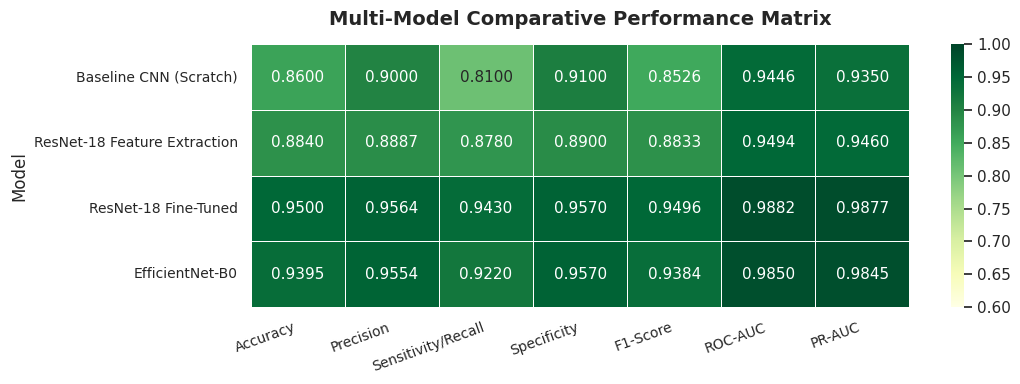

In [17]:
# ── Consolidated Metrics Table ───────────────────────────────────────────────
models_evaluated = [
    ('Baseline CNN (Scratch)',            metrics_baseline, probs_baseline, labels_baseline),
    ('ResNet-18 Feature Extraction',      metrics_fe,       probs_fe,       labels_fe),
    ('ResNet-18 Fine-Tuned',              metrics_ft,       probs_ft,       labels_ft),
    ('EfficientNet-B0',                   metrics_eff,      probs_eff,      labels_eff),
]

rows = []
for name, m, _, _ in models_evaluated:
    rows.append({
        'Model':              name,
        'Accuracy':           f"{m['accuracy']:.4f}",
        'Precision':          f"{m['precision']:.4f}",
        'Sensitivity/Recall': f"{m['recall']:.4f}",
        'Specificity':        f"{m['specificity']:.4f}",
        'F1-Score':           f"{m['f1']:.4f}",
        'ROC-AUC':            f"{m['roc_auc']:.4f}",
        'PR-AUC':             f"{m['pr_auc']:.4f}",
    })

df_comparison = pd.DataFrame(rows).set_index('Model')
print("\n" + "="*90)
print("  FINAL MODEL COMPARISON TABLE (TEST SET EVALUATION)")
print("="*90)
display(df_comparison)
print("="*90)

# ── Comparison Table Heatmap ─────────────────────────────────────────────────
numeric_df = df_comparison.copy().astype(float)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    numeric_df,
    annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, linecolor='white', ax=ax, vmin=0.6, vmax=1.0,
    annot_kws={'size': 11}
)
ax.set_title("Multi-Model Comparative Performance Matrix", fontsize=14, fontweight='bold', pad=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'comparison_table_heatmap.png', dpi=150)
plt.show()

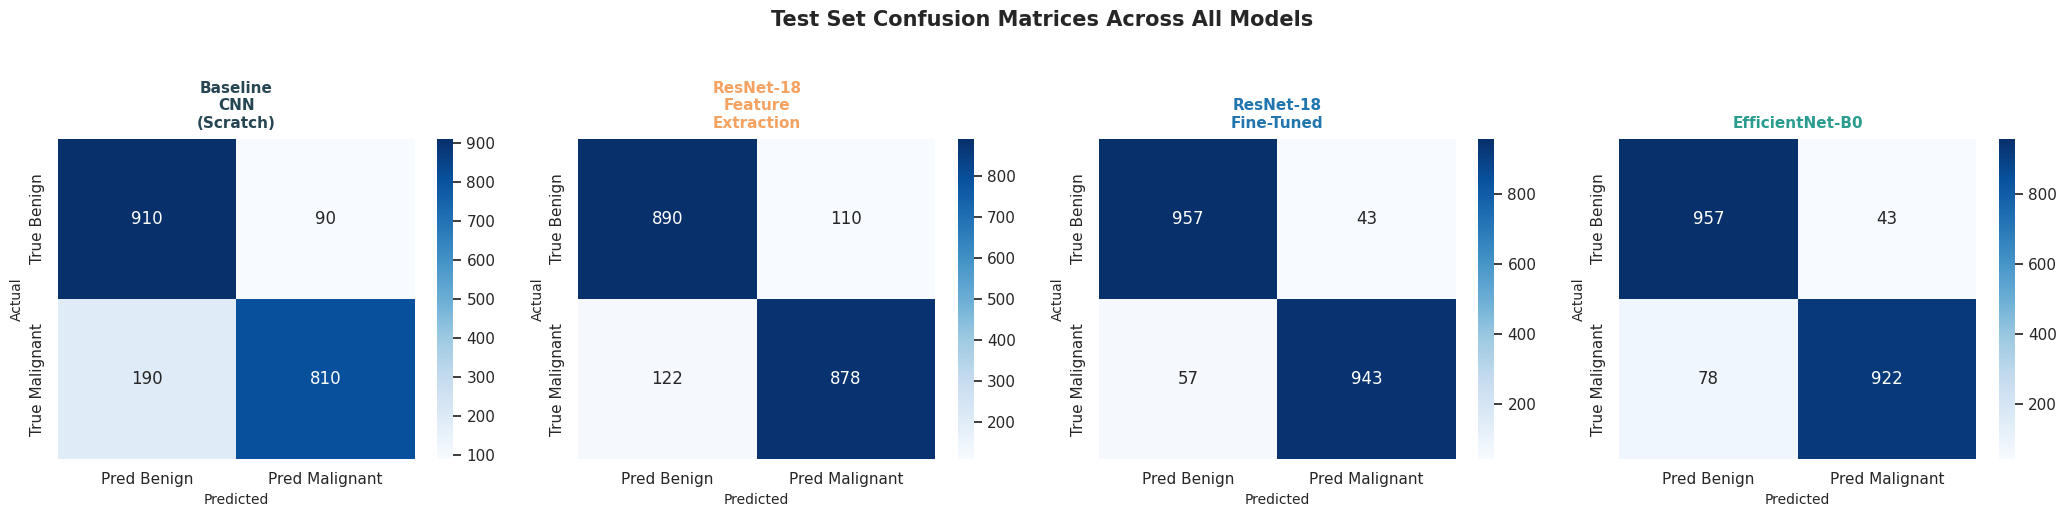

In [18]:
# ── Side-by-Side Confusion Matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(21, 5))
colors = ['#264653', '#F4A261', '#2176AE', '#2A9D8F']

for ax, (name, m, _, _), color in zip(axes, models_evaluated, colors):
    cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pred Benign', 'Pred Malignant'],
        yticklabels=['True Benign', 'True Malignant'],
        annot_kws={'size': 12}
    )
    ax.set_title(name.replace(' ', '\n'), fontsize=11, fontweight='bold', color=color, pad=8)
    ax.set_ylabel("Actual", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)

plt.suptitle("Test Set Confusion Matrices Across All Models", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / 'side_by_side_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

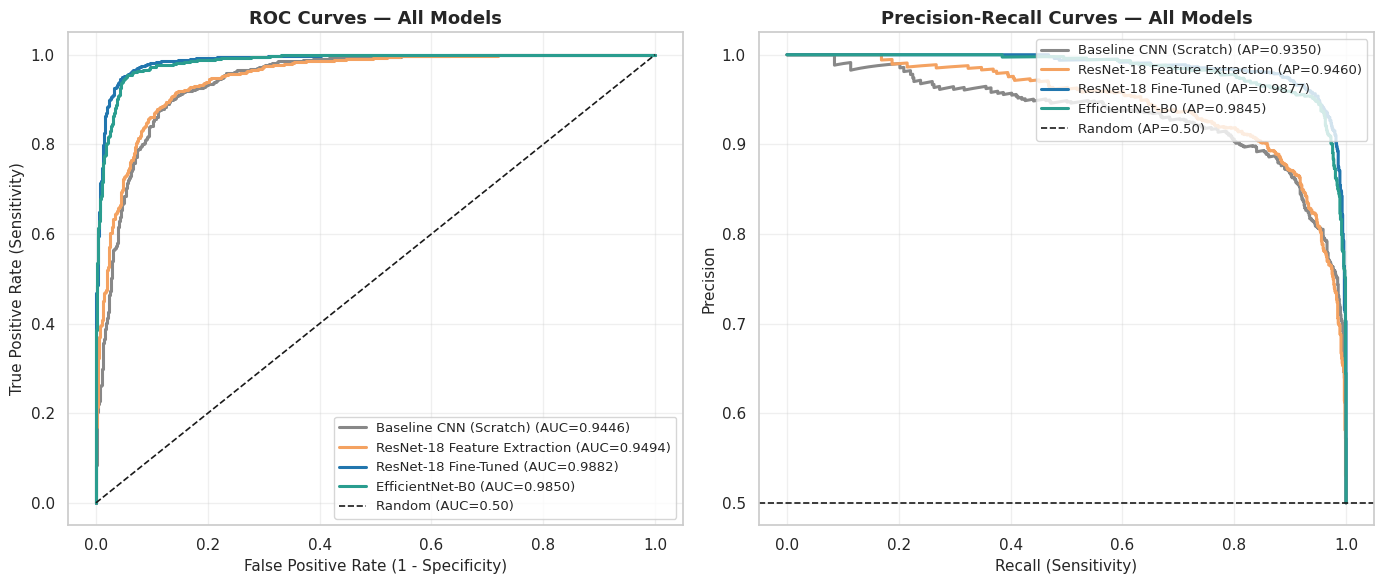

In [19]:
# ── ROC & Precision-Recall Curves Comparison ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
palette = {
    'Baseline CNN (Scratch)':        '#888888',
    'ResNet-18 Feature Extraction':  '#F4A261',
    'ResNet-18 Fine-Tuned':          '#2176AE',
    'EfficientNet-B0':               '#2A9D8F',
}

for name, _, probs, labels in models_evaluated:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax1.plot(fpr, tpr, lw=2.2, color=palette[name], label=f"{name} (AUC={auc:.4f})")

    prec, rec, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)
    ax2.plot(rec, prec, lw=2.2, color=palette[name], label=f"{name} (AP={ap:.4f})")

ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.50)')
ax1.set_title("ROC Curves — All Models", fontsize=13, fontweight='bold')
ax1.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax1.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax1.legend(loc='lower right', fontsize=9.5)
ax1.grid(alpha=0.3)

baseline_pr = labels_baseline.mean()
ax2.axhline(y=baseline_pr, color='k', linestyle='--', lw=1.2, label=f'Random (AP={baseline_pr:.2f})')
ax2.set_title("Precision-Recall Curves — All Models", fontsize=13, fontweight='bold')
ax2.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.legend(loc='upper right', fontsize=9.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'roc_and_pr_curves_comparison.png', dpi=150)
plt.show()

# Part 7: Stage 5 — Diagnostic Misclassification Analysis
We automatically identify the best-performing model by ROC-AUC and visually inspect its False Positives (over-diagnosis) and False Negatives (missed melanomas).

In [20]:
# Select Best Model
best_name, best_m, best_probs, best_labels = max(models_evaluated, key=lambda x: x[1]['roc_auc'])
print(f"Best Performing Model: {best_name} (ROC-AUC: {best_m['roc_auc']:.4f}, Accuracy: {best_m['accuracy']:.4f})")

test_paths = [s[0] for s in test_ldr_im.dataset.samples]
best_preds = (best_probs >= 0.5).astype(int)

fp_indices = np.where((best_preds == 1) & (best_labels == 0))[0]
fn_indices = np.where((best_preds == 0) & (best_labels == 1))[0]

print(f"  False Positives (Benign misclassified as Malignant): {len(fp_indices)}")
print(f"  False Negatives (Malignant missed as Benign)        : {len(fn_indices)} [CRITICAL CLINICAL RISK]")

Best Performing Model: ResNet-18 Fine-Tuned (ROC-AUC: 0.9882, Accuracy: 0.9500)
  False Positives (Benign misclassified as Malignant): 43
  False Negatives (Malignant missed as Benign)        : 57 [CRITICAL CLINICAL RISK]


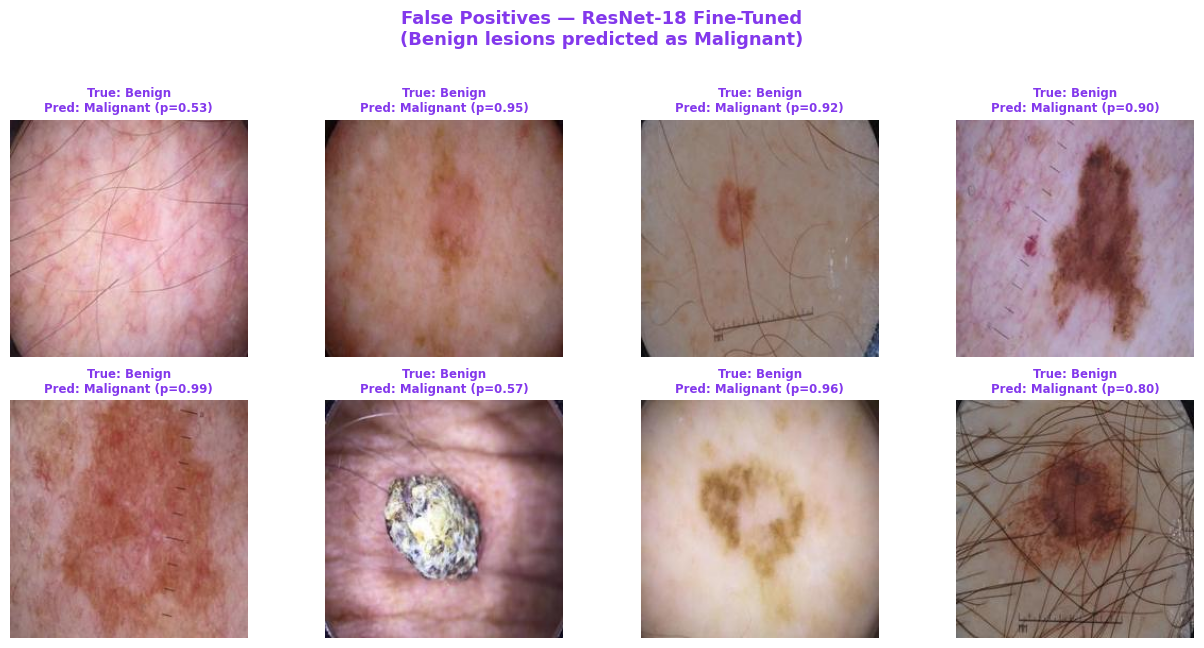

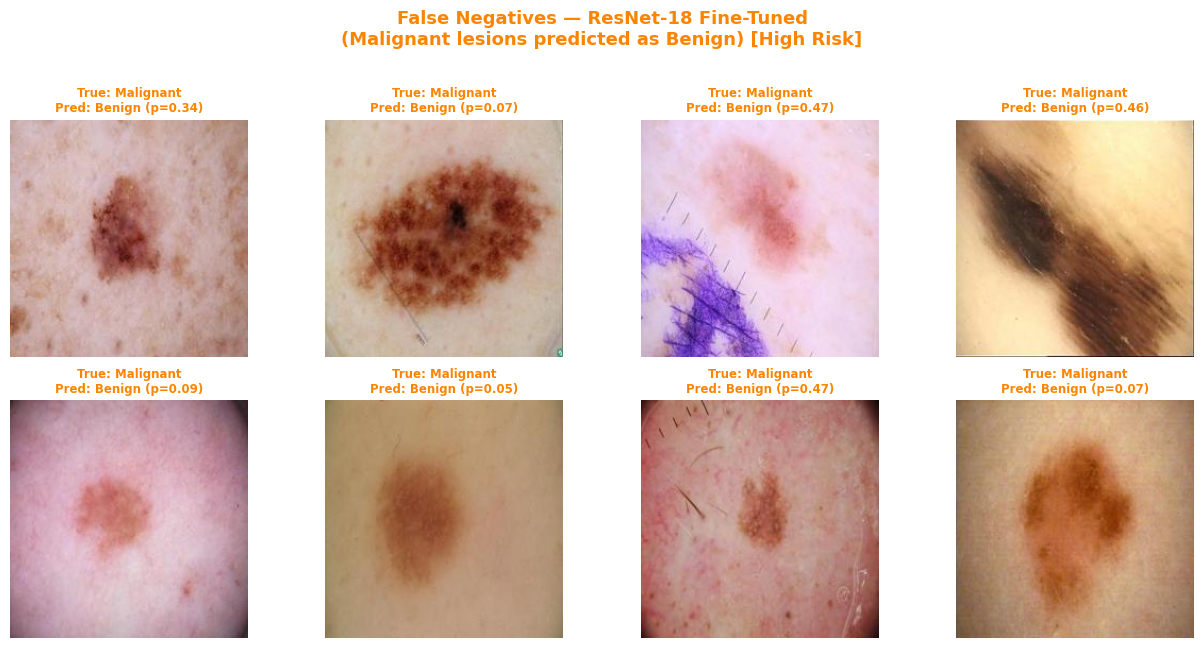

In [21]:
def display_error_grid(indices, title, header_color, is_fp=True, n_show=8):
    if len(indices) == 0:
        print(f"No error samples for {title}")
        return
    rng = np.random.default_rng(SEED)
    selected = rng.choice(indices, size=min(n_show, len(indices)), replace=False)
    n_cols = 4
    n_rows = (len(selected) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.2))
    axes = np.array(axes).reshape(-1)

    for ax_idx, img_idx in enumerate(selected):
        ax = axes[ax_idx]
        img = Image.open(test_paths[img_idx]).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        p = best_probs[img_idx]
        true_str = "Benign" if best_labels[img_idx] == 0 else "Malignant"
        pred_str = "Malignant" if is_fp else "Benign"
        ax.set_title(f"True: {true_str}\nPred: {pred_str} (p={p:.2f})", fontsize=8.5, color=header_color, fontweight='bold')

    for ax in axes[len(selected):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold', color=header_color, y=1.01)
    plt.tight_layout()
    plt.show()

display_error_grid(fp_indices, f"False Positives — {best_name}\n(Benign lesions predicted as Malignant)", '#8338EC', is_fp=True)
display_error_grid(fn_indices, f"False Negatives — {best_name}\n(Malignant lesions predicted as Benign) [High Risk]", '#FB8500', is_fp=False)

# Part 8: Stage 6 — Explainable AI via Grad-CAM Saliency Mapping
We implement hook-based Grad-CAM to visualize the spatial regions influencing model decisions:
$$\text{CAM} = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right), \quad \alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A_{i,j}^k}$$

We generate:
1. **ResNet-18 Fine-Tuned Grad-CAM Grid** across 4 clinical decision categories.
2. **Baseline CNN Grad-CAM Grid**.
3. **Side-by-Side Diagnostic Comparison (Disagreement Cases)**.

In [22]:
class GradCAM:
    """Hook-based Grad-CAM implementation for PyTorch CNNs."""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.fmaps = None
        self.grads = None
        self.fwd_hook = target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'fmaps', o.detach()))
        self.bwd_hook = target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        logit = self.model(x).squeeze()
        logit.backward()

        alpha = self.grads.squeeze(0).mean(dim=(-2, -1))
        cam   = (alpha[:, None, None] * self.fmaps.squeeze(0)).sum(0)
        cam   = torch.relu(cam).cpu().numpy()

        h, w = x.shape[-2], x.shape[-1]
        cam  = cv2.resize(cam, (w, h))
        mn, mx = cam.min(), cam.max()
        return ((cam - mn) / (mx - mn + 1e-8)).astype(np.float32)

    def remove(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

def denormalize_img(tensor, mean, std):
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    arr = (tensor.cpu() * s + m).permute(1, 2, 0).numpy()
    return (np.clip(arr, 0, 1) * 255).astype(np.uint8)

def create_gradcam_overlay(img_rgb, heatmap, alpha=0.45):
    hm_uint8 = (heatmap * 255).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    return (alpha * hm_color + (1 - alpha) * img_rgb).astype(np.uint8)

print("Grad-CAM engine initialized.")

Grad-CAM engine initialized.


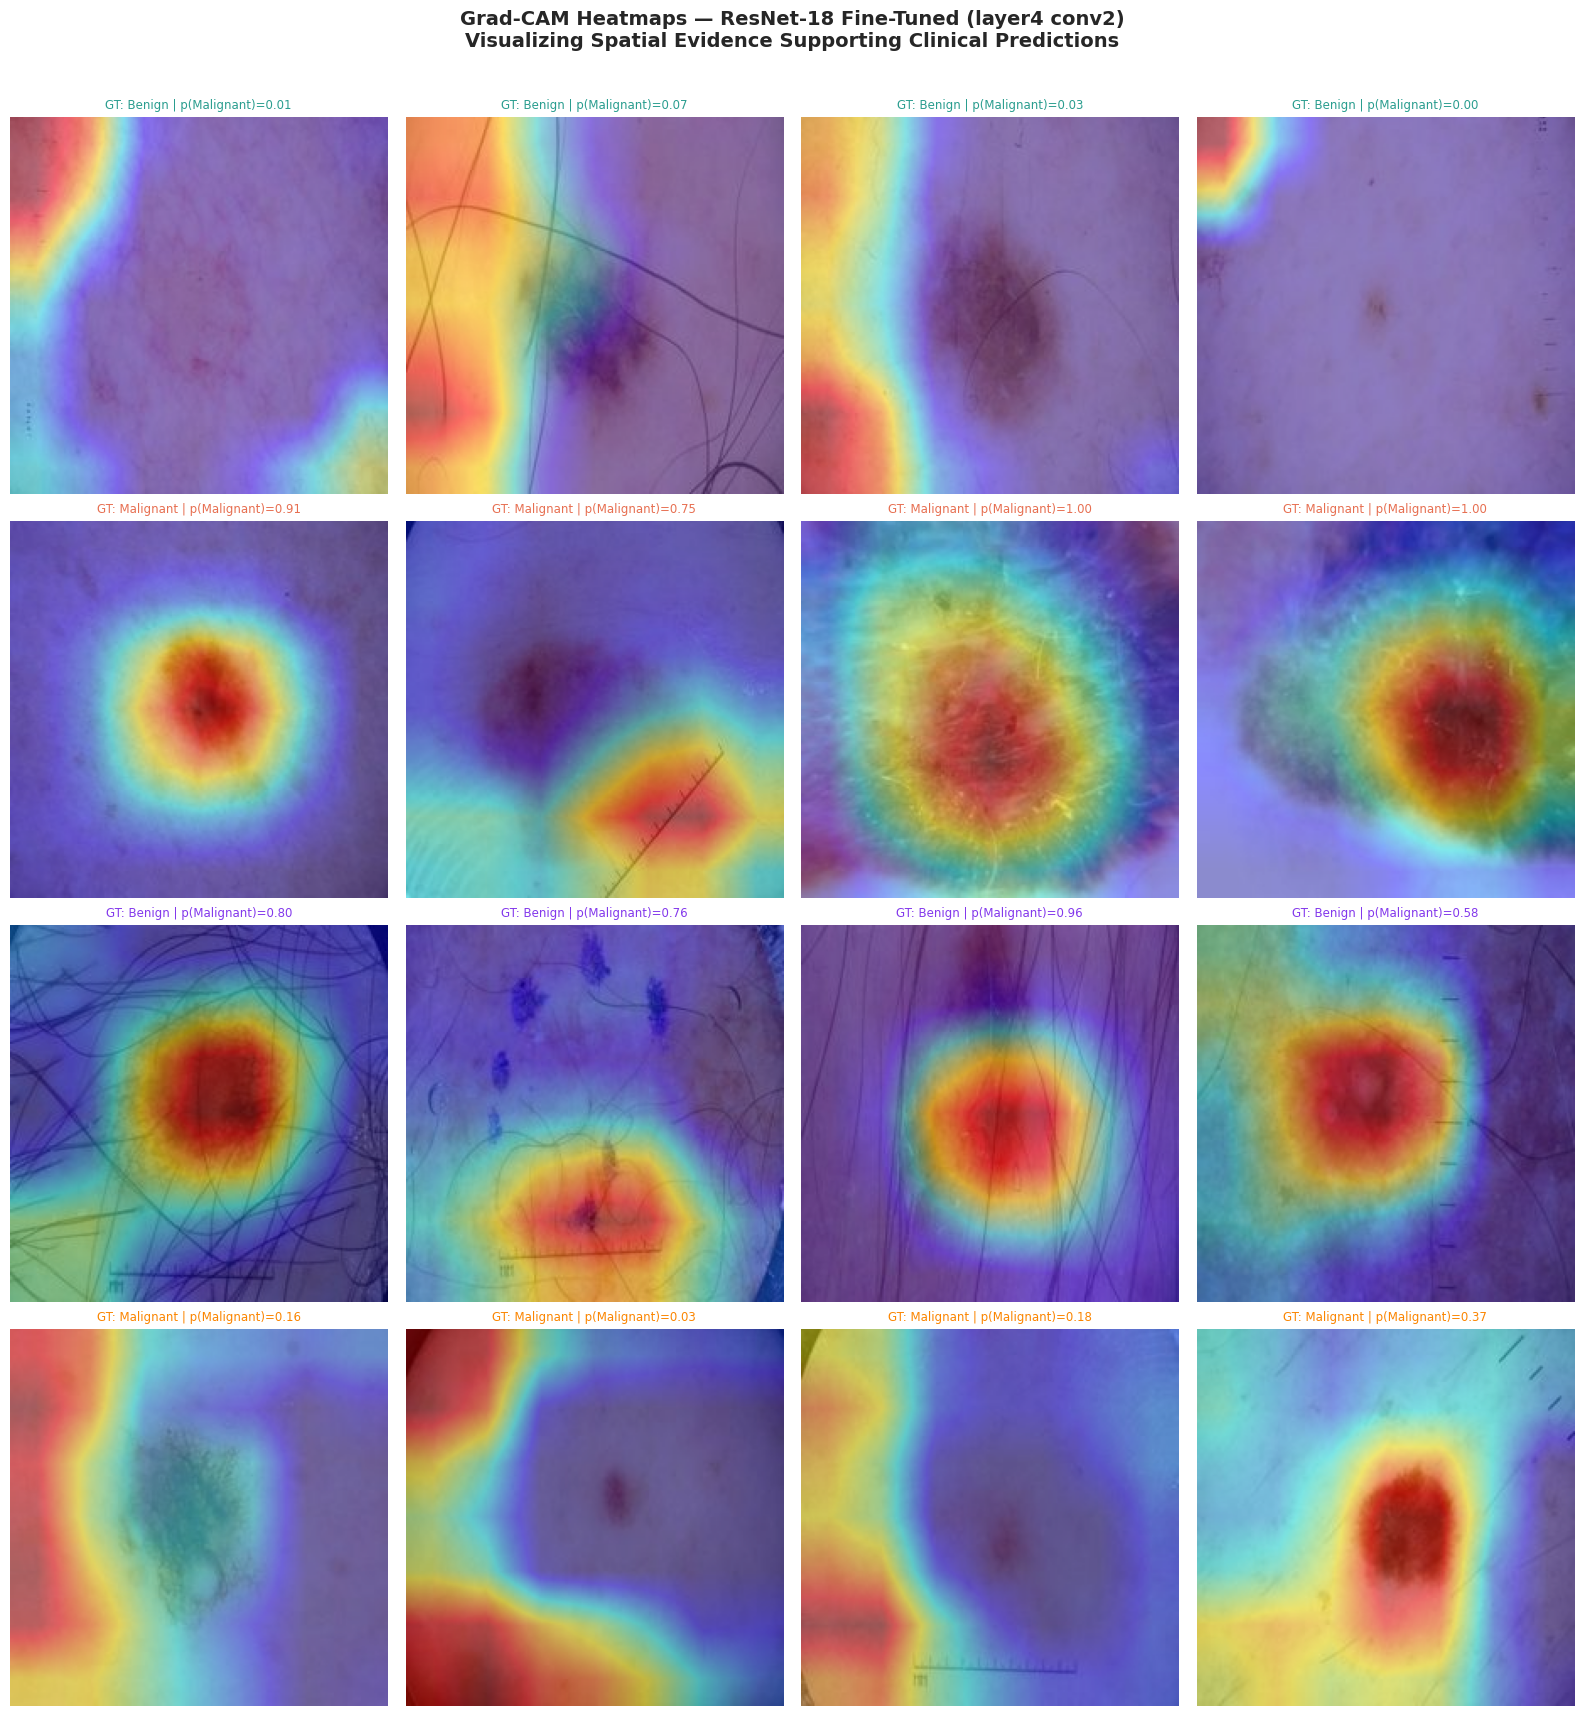

In [23]:
# ── 1. ResNet-18 Grad-CAM Grid Across 4 Clinical Groups ───────────────────────
target_layer_resnet = model_ft.layer4[-1].conv2
gcam_resnet = GradCAM(model_ft, target_layer_resnet)

rng = np.random.default_rng(SEED)
def sample_idx(mask, n=4):
    idx = np.where(mask)[0]
    return rng.choice(idx, size=min(n, len(idx)), replace=False)

# Use ResNet-18's OWN predictions here — not whichever model happened to
# win best ROC-AUC in Part 7 — so the group labels and probabilities match
# the model whose CAM is actually being rendered.
preds_ft = (probs_ft >= 0.5).astype(int)

idx_cb = sample_idx((preds_ft == 0) & (labels_ft == 0), 4)  # Correct Benign
idx_cm = sample_idx((preds_ft == 1) & (labels_ft == 1), 4)  # Correct Malignant
idx_fp = sample_idx((preds_ft == 1) & (labels_ft == 0), 4)  # False Positive
idx_fn = sample_idx((preds_ft == 0) & (labels_ft == 1), 4)  # False Negative

cam_groups = [
    ('Correct Benign',    idx_cb, '#2A9D8F'),
    ('Correct Malignant', idx_cm, '#E76F51'),
    ('False Positive',    idx_fp, '#8338EC'),
    ('False Negative',    idx_fn, '#FB8500'),
]

fig = plt.figure(figsize=(16, 17))
fig.suptitle("Grad-CAM Heatmaps — ResNet-18 Fine-Tuned (layer4 conv2)\nVisualizing Spatial Evidence Supporting Clinical Predictions",
             fontsize=14, fontweight='bold', y=1.01)

for row, (group_name, indices, color) in enumerate(cam_groups):
    for col, img_idx in enumerate(indices):
        ax = fig.add_subplot(4, 4, row * 4 + col + 1)
        img_tensor, true_lbl = test_ldr_im.dataset[img_idx]
        hmap = gcam_resnet(img_tensor.unsqueeze(0).to(DEVICE))
        rgb  = denormalize_img(img_tensor, IMAGENET_MEAN, IMAGENET_STD)
        overlay = create_gradcam_overlay(rgb, hmap)

        ax.imshow(overlay)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(group_name, color=color, fontsize=11, fontweight='bold', labelpad=8)
        prob = probs_ft[img_idx]     # ResNet-18's own probability, not best_probs
        gt_str = CLASS_NAMES[true_lbl].capitalize()
        ax.set_title(f"GT: {gt_str} | p(Malignant)={prob:.2f}", fontsize=8.5, color=color)

plt.tight_layout()
fig.savefig(FIG_DIR / 'gradcam_resnet18_fine_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
gcam_resnet.remove()

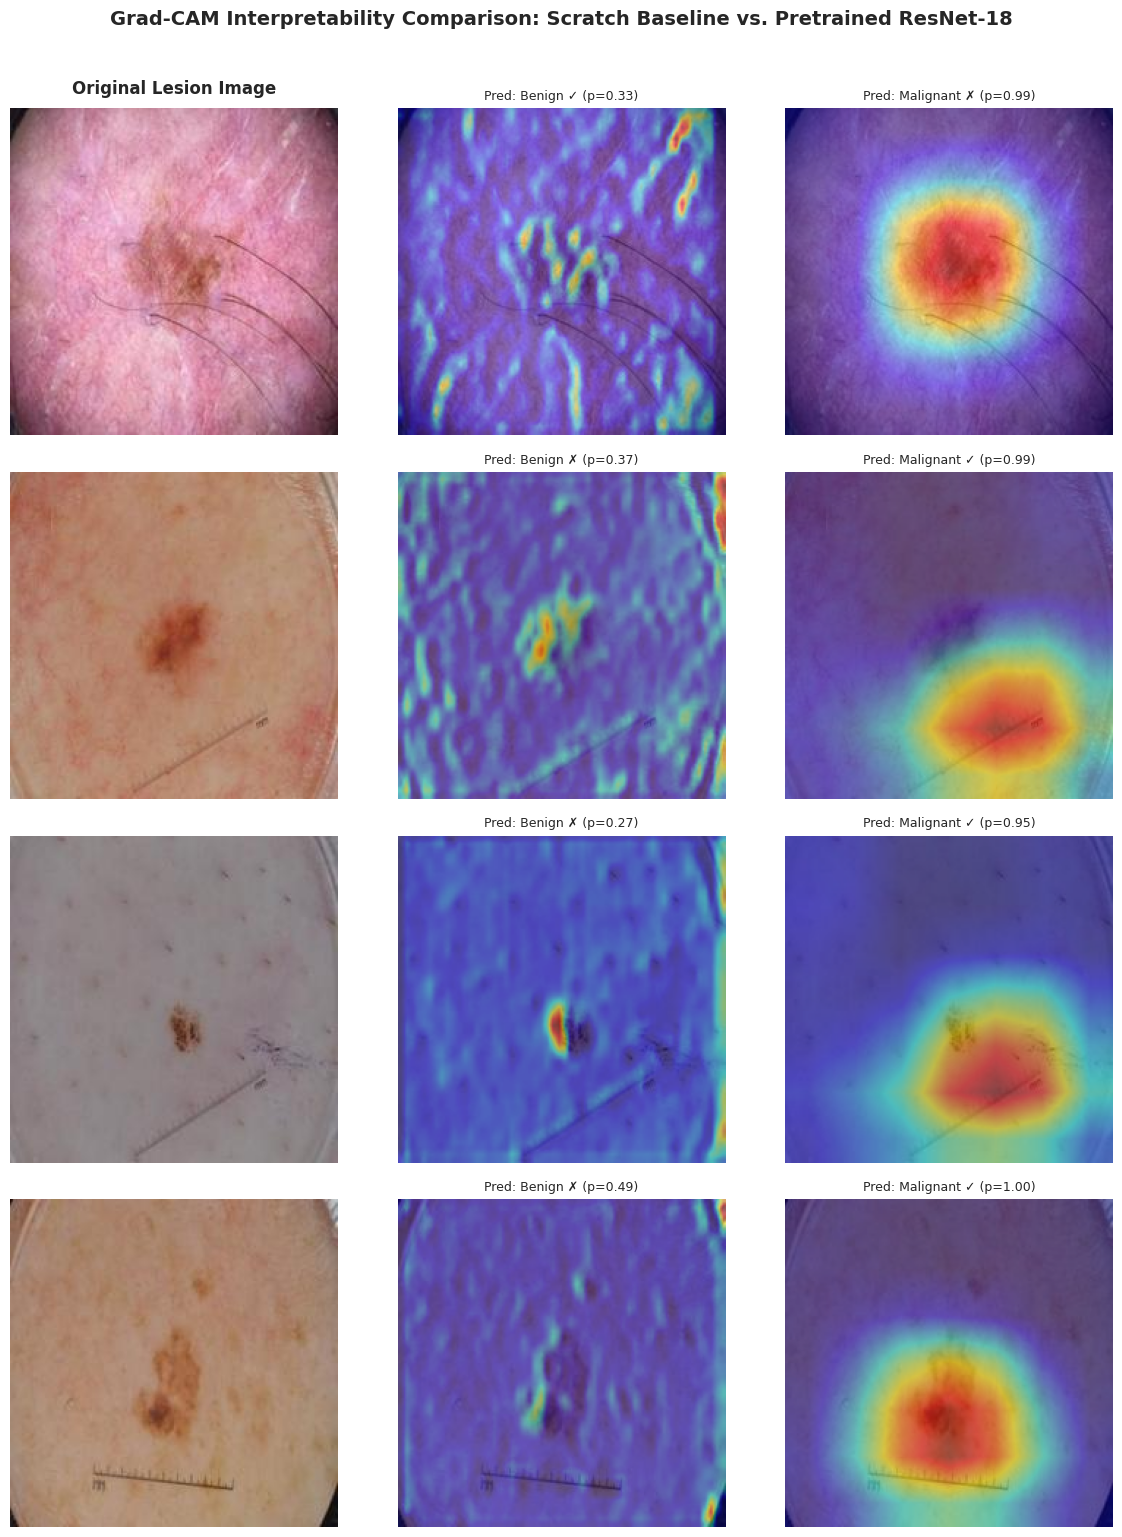

In [24]:
# ── 2. Side-by-Side Model Comparison: Baseline CNN vs ResNet-18 ──────────────
target_layer_cnn = model_baseline.features[-1].block[0]
gcam_cnn = GradCAM(model_baseline, target_layer_cnn)
gcam_r   = GradCAM(model_ft,       model_ft.layer4[-1].conv2)

# Find cases where Baseline CNN and ResNet-18 SPECIFICALLY disagree
# (not "baseline vs whichever model won ROC-AUC" — that could silently
# become a baseline-vs-EfficientNet comparison mislabeled as ResNet-18)
preds_b  = (probs_baseline >= 0.5).astype(int)
preds_ft = (probs_ft >= 0.5).astype(int)
disagree = np.where(preds_b != preds_ft)[0]
if len(disagree) >= 4:
    compare_indices = rng.choice(disagree, size=4, replace=False)
else:
    compare_indices = rng.choice(range(len(labels_ft)), size=4, replace=False)

fig, axes = plt.subplots(len(compare_indices), 3, figsize=(12, len(compare_indices) * 3.8))
col_titles = ['Original Lesion Image', 'Baseline CNN (Scratch) CAM', 'ResNet-18 Fine-Tuned CAM']
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=12, fontweight='bold', pad=10)

for row, img_idx in enumerate(compare_indices):
    # Original
    orig_p = test_paths[img_idx]
    orig_img = Image.open(orig_p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[row, 0].imshow(orig_img)
    axes[row, 0].axis('off')
    gt_str = CLASS_NAMES[labels_ft[img_idx]].capitalize()
    axes[row, 0].set_ylabel(f"GT: {gt_str}", fontsize=11, fontweight='bold', labelpad=8)

    # Baseline CAM
    img_b_tensor, _ = test_ldr_ds.dataset[img_idx]
    hmap_b = gcam_cnn(img_b_tensor.unsqueeze(0).to(DEVICE))
    rgb_b  = denormalize_img(img_b_tensor, DATASET_MEAN, DATASET_STD)
    axes[row, 1].imshow(create_gradcam_overlay(rgb_b, hmap_b))
    axes[row, 1].axis('off')
    p_b = probs_baseline[img_idx]
    pred_b_str = CLASS_NAMES[int(p_b >= 0.5)].capitalize()
    mark_b = "✓" if (p_b >= 0.5) == labels_ft[img_idx] else "✗"
    axes[row, 1].set_title(f"Pred: {pred_b_str} {mark_b} (p={p_b:.2f})", fontsize=9)

    # ResNet-18 CAM
    img_r_tensor, _ = test_ldr_im.dataset[img_idx]
    hmap_r = gcam_r(img_r_tensor.unsqueeze(0).to(DEVICE))
    rgb_r  = denormalize_img(img_r_tensor, IMAGENET_MEAN, IMAGENET_STD)
    axes[row, 2].imshow(create_gradcam_overlay(rgb_r, hmap_r))
    axes[row, 2].axis('off')
    p_r = probs_ft[img_idx]          # ResNet-18's own probability, not best_probs
    pred_r_str = CLASS_NAMES[int(p_r >= 0.5)].capitalize()
    mark_r = "✓" if (p_r >= 0.5) == labels_ft[img_idx] else "✗"
    axes[row, 2].set_title(f"Pred: {pred_r_str} {mark_r} (p={p_r:.2f})", fontsize=9)

plt.suptitle("Grad-CAM Interpretability Comparison: Scratch Baseline vs. Pretrained ResNet-18",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'gradcam_baseline_vs_resnet18_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

gcam_cnn.remove()
gcam_r.remove()

# Part 9: Summary & Export Final Metrics JSON

In [25]:
# ── Save metrics.json for programmatic verification ─────────────────────────
final_metrics_dict = {
    'baseline_cnn':                 metrics_baseline,
    'resnet18_feature_extraction':  metrics_fe,
    'resnet18_fine_tuned':          metrics_ft,
    'efficientnet_b0':              metrics_eff,
}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(final_metrics_dict, f, indent=2)

print("="*80)
print(f"[✓] Master Execution Completed Successfully!")
print(f"[✓] Metrics JSON exported to: {OUT_DIR / 'metrics.json'}")
print(f"[✓] All figures generated in: {FIG_DIR}")
print("="*80)
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  • {p.relative_to(OUT_DIR)}")

[✓] Master Execution Completed Successfully!
[✓] Metrics JSON exported to: /kaggle/working/metrics.json
[✓] All figures generated in: /kaggle/working/figures
  • .virtual_documents/__notebook_source__.ipynb
  • baseline_cnn.pt
  • efficientnet_b0.pt
  • figures/comparison_table_heatmap.png
  • figures/dataset_class_distribution.png
  • figures/gradcam_baseline_vs_resnet18_comparison.png
  • figures/gradcam_resnet18_fine_tuned.png
  • figures/roc_and_pr_curves_comparison.png
  • figures/sample_images_inspection.png
  • figures/side_by_side_confusion_matrices.png
  • figures/training_curves_baseline.png
  • figures/training_curves_efficientnet_b0.png
  • figures/training_curves_resnet18_feat_ext.png
  • figures/training_curves_resnet18_fine_tuned.png
  • metrics.json
  • resnet18_feature_extraction.pt
  • resnet18_fine_tuned.pt
